<a href="https://colab.research.google.com/github/vijaydevverse/ML-DL-Projects-Portfolio/blob/main/AI_Powered_Resume_Screening_and_Candidate_Selection_Prediction_System_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement

Resume screening is a crucial step in the recruitment process, where organizations evaluate large volumes of applications to identify suitable candidates for specific job roles. Traditional screening methods require significant time and effort from recruiters, making the process inefficient and prone to human bias. With the increasing adoption of Artificial Intelligence and Machine Learning in Human Resource Management, automated resume screening systems have become an effective solution for streamlining candidate evaluation and improving hiring efficiency.

In this project, we develop a Resume Screening System that predicts whether a candidate is likely to be selected based on various attributes such as age, education, work experience, technical skills, job role, and candidate-job matching information. Using machine learning techniques, the system analyzes patterns in historical recruitment data and learns the factors that influence hiring decisions. The objective is to accurately predict the target variable Selected (0 = Not Selected, 1 = Selected), enabling recruiters to identify qualified candidates more efficiently and support data-driven talent acquisition.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv('/content/Resume_Screening_System_100K.csv')
df

,Candidate_ID,Candidate_Name,Age,Education,Experience_Years,Location,Applied_Role,Resume_Skills,Job_Description_Skills,Matched_Skills_Count,Candidate_Match_Score,Selected
0,CAND000001,Elizabeth Santos,37,MBA,8,Delhi,AI Engineer,"Streamlit, Machine Learning, Tableau, Azure, G...","Git, Streamlit, Docker, TensorFlow, Azure, Dee...",3,50.00,0
1,CAND000002,Allen Duke,23,MCA,9,Bangalore,ML Engineer,"Power BI, Docker, PyTorch, Tableau, Streamlit,...","Streamlit, Python, Data Analysis, SQL, TensorF...",3,42.86,0
2,CAND000003,Bobby Williams,26,MBA,12,Mumbai,ML Engineer,"PyTorch, AWS, Kubernetes, Git","Azure, Machine Learning, Java, React, LLMs",0,0.00,0
3,CAND000004,Karen Stephens,36,M.Tech,15,Mumbai,Data Analyst,"Streamlit, Java, Node.js, PyTorch, Git, LLMs, AWS","Python, Azure, React, Power BI, TensorFlow, LL...",2,25.00,0
4,CAND000005,Teresa Castro,38,M.Sc,10,Chennai,AI Engineer,"React, Kubernetes, Azure, Power BI, Tableau, D...","Docker, Deep Learning, Node.js, Streamlit, Azu...",4,57.14,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CAND099996,Mr. Ronald Ray,32,MBA,14,Mumbai,Python Developer,"SQL, Node.js, PyTorch, TensorFlow","LLMs, Git, Power BI, TensorFlow, Kubernetes, D...",1,16.67,0
99996,CAND099997,Brian Moore,43,B.Tech,1,Pune,Software Engineer,"AWS, Deep Learning, Git, LLMs, SQL, Streamlit,...","Machine Learning, Java, AWS, Docker, Data Anal...",1,20.00,0
99997,CAND099998,Sue Cordova,33,M.Sc,3,Chennai,Data Scientist,"NLP, Kubernetes, React, Docker, Streamlit, AWS...","Git, AWS, Machine Learning, Tableau, Java",2,40.00,0
99998,CAND099999,Justin Smith,36,M.Sc,7,Hyderabad,Data Analyst,"SQL, NLP, React, LLMs, Java, Data Analysis","NLP, LLMs, Azure, Git, PyTorch, Data Analysis,...",3,42.86,0


In [ ]:
df.head()

,Candidate_ID,Candidate_Name,Age,Education,Experience_Years,Location,Applied_Role,Resume_Skills,Job_Description_Skills,Matched_Skills_Count,Candidate_Match_Score,Selected
0,CAND000001,Elizabeth Santos,37,MBA,8,Delhi,AI Engineer,"Streamlit, Machine Learning, Tableau, Azure, G...","Git, Streamlit, Docker, TensorFlow, Azure, Dee...",3,50.00,0
1,CAND000002,Allen Duke,23,MCA,9,Bangalore,ML Engineer,"Power BI, Docker, PyTorch, Tableau, Streamlit,...","Streamlit, Python, Data Analysis, SQL, TensorF...",3,42.86,0
2,CAND000003,Bobby Williams,26,MBA,12,Mumbai,ML Engineer,"PyTorch, AWS, Kubernetes, Git","Azure, Machine Learning, Java, React, LLMs",0,0.00,0
3,CAND000004,Karen Stephens,36,M.Tech,15,Mumbai,Data Analyst,"Streamlit, Java, Node.js, PyTorch, Git, LLMs, AWS","Python, Azure, React, Power BI, TensorFlow, LL...",2,25.00,0
4,CAND000005,Teresa Castro,38,M.Sc,10,Chennai,AI Engineer,"React, Kubernetes, Azure, Power BI, Tableau, D...","Docker, Deep Learning, Node.js, Streamlit, Azu...",4,57.14,0


In [ ]:
df.tail()

,Candidate_ID,Candidate_Name,Age,Education,Experience_Years,Location,Applied_Role,Resume_Skills,Job_Description_Skills,Matched_Skills_Count,Candidate_Match_Score,Selected
99995,CAND099996,Mr. Ronald Ray,32,MBA,14,Mumbai,Python Developer,"SQL, Node.js, PyTorch, TensorFlow","LLMs, Git, Power BI, TensorFlow, Kubernetes, D...",1,16.67,0
99996,CAND099997,Brian Moore,43,B.Tech,1,Pune,Software Engineer,"AWS, Deep Learning, Git, LLMs, SQL, Streamlit,...","Machine Learning, Java, AWS, Docker, Data Anal...",1,20.00,0
99997,CAND099998,Sue Cordova,33,M.Sc,3,Chennai,Data Scientist,"NLP, Kubernetes, React, Docker, Streamlit, AWS...","Git, AWS, Machine Learning, Tableau, Java",2,40.00,0
99998,CAND099999,Justin Smith,36,M.Sc,7,Hyderabad,Data Analyst,"SQL, NLP, React, LLMs, Java, Data Analysis","NLP, LLMs, Azure, Git, PyTorch, Data Analysis,...",3,42.86,0
99999,CAND100000,Michael Walker,23,M.Sc,12,Bangalore,Data Scientist,"Kubernetes, Streamlit, LLMs, AWS, Java, Machin...","Power BI, NLP, Azure, AWS, Machine Learning, L...",4,57.14,0


In [ ]:
df.shape

(100000, 12)

In [ ]:
df.columns

Index(['Candidate_ID', 'Candidate_Name', 'Age', 'Education',
       'Experience_Years', 'Location', 'Applied_Role', 'Resume_Skills',
       'Job_Description_Skills', 'Matched_Skills_Count',
       'Candidate_Match_Score', 'Selected'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Candidate_ID            100000 non-null  object 
 1   Candidate_Name          100000 non-null  object 
 2   Age                     100000 non-null  int64  
 3   Education               100000 non-null  object 
 4   Experience_Years        100000 non-null  int64  
 5   Location                100000 non-null  object 
 6   Applied_Role            100000 non-null  object 
 7   Resume_Skills           100000 non-null  object 
 8   Job_Description_Skills  100000 non-null  object 
 9   Matched_Skills_Count    100000 non-null  int64  
 10  Candidate_Match_Score   100000 non-null  float64
 11  Selected                100000 non-null  int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 9.2+ MB


In [ ]:
df.isnull().sum()

,0
Candidate_ID,0
Candidate_Name,0
Age,0
Education,0
Experience_Years,0
Location,0
Applied_Role,0
Resume_Skills,0
Job_Description_Skills,0
Matched_Skills_Count,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target='Selected'

In [ ]:
df[target].value_counts()

,count
Selected,
0,87348
1,12652


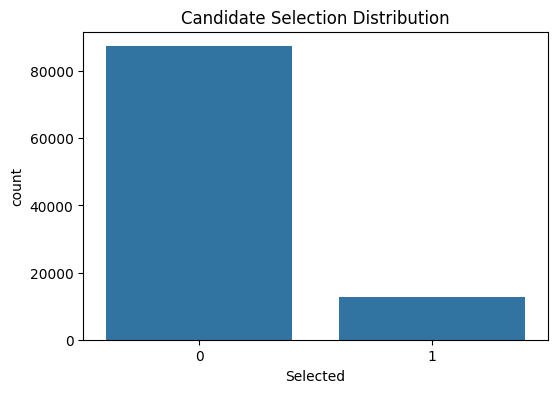

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("Candidate Selection Distribution")
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['Candidate_ID', 'Candidate_Name', 'Education', 'Location',
       'Applied_Role', 'Resume_Skills', 'Job_Description_Skills'],
      dtype='object')

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Age', 'Experience_Years', 'Matched_Skills_Count',
       'Candidate_Match_Score', 'Selected'],
      dtype='object')

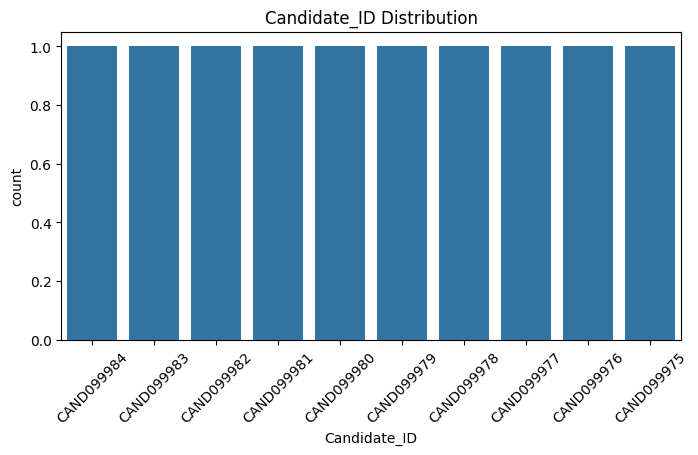

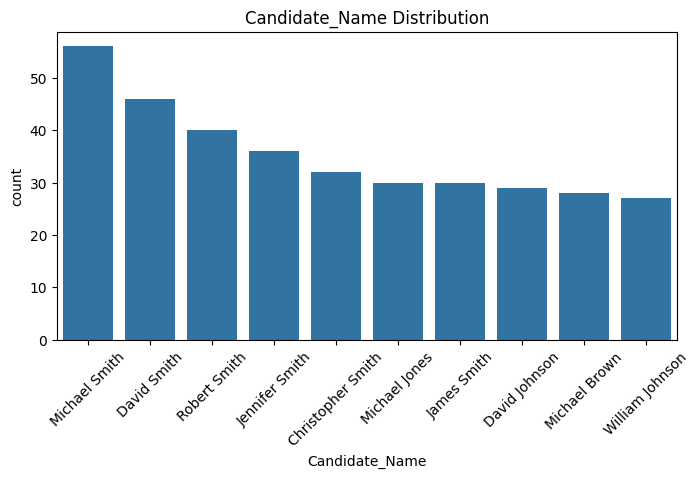

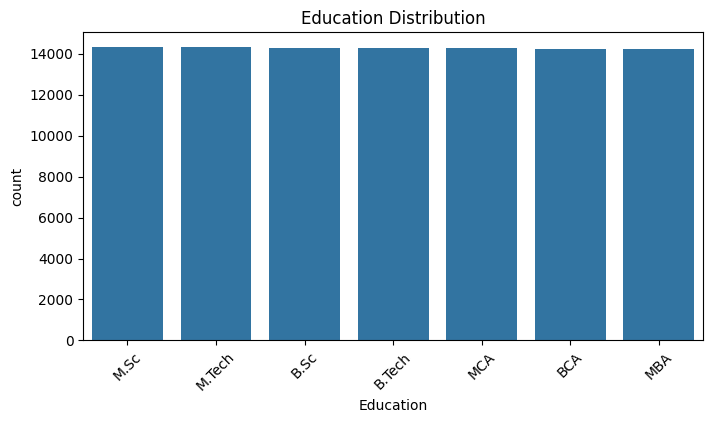

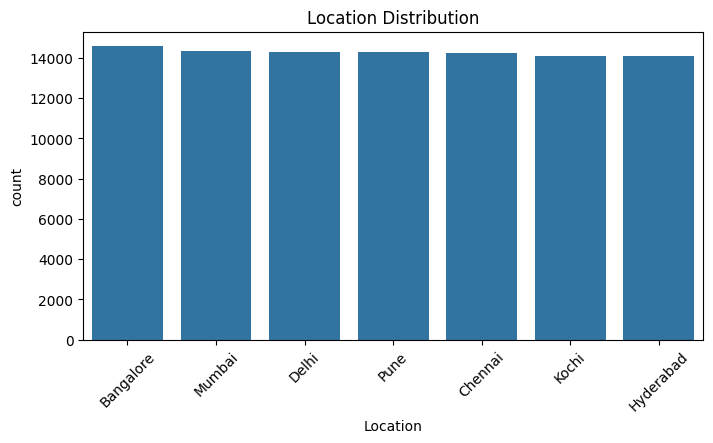

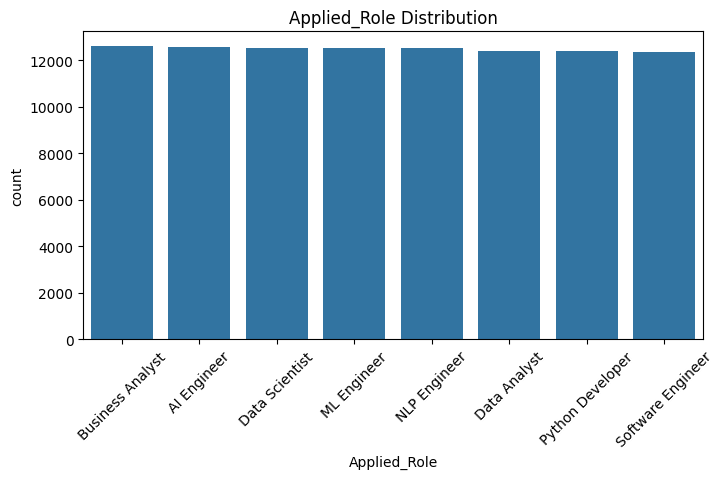

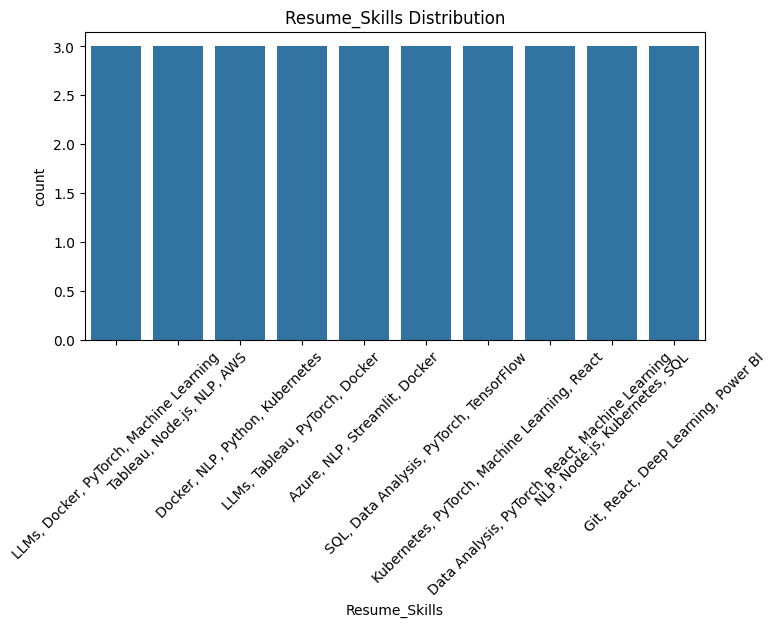

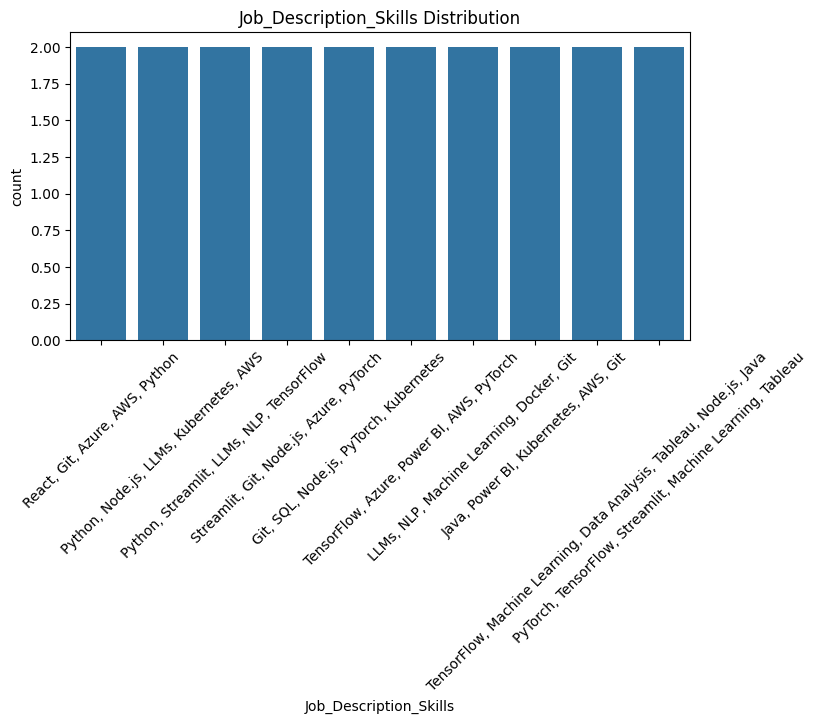

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
    plt.xticks(rotation=45)
    plt.title(f'{col} Distribution')
    plt.show()

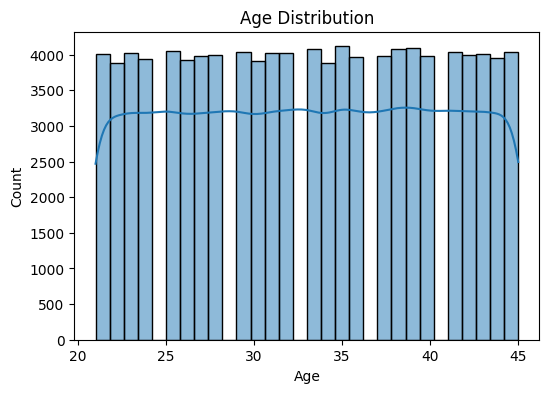

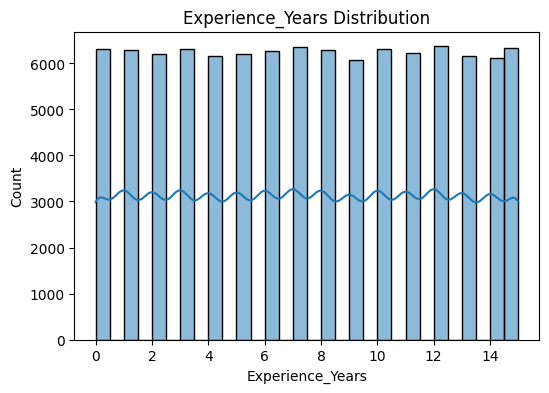

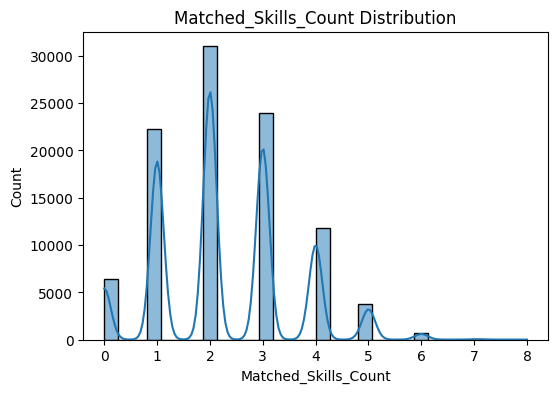

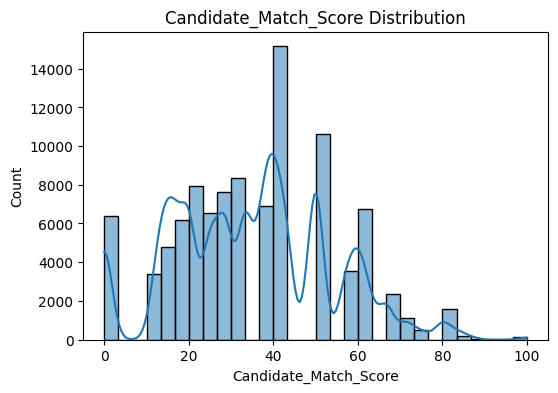

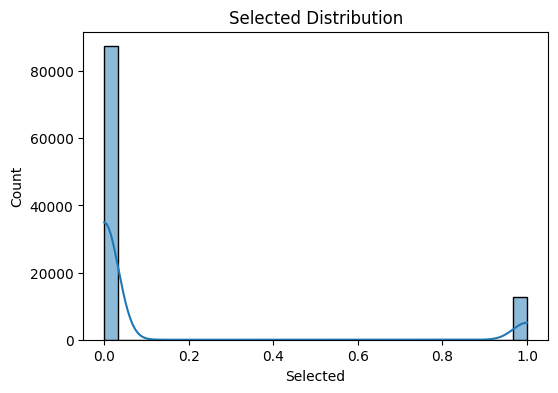

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=30,kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

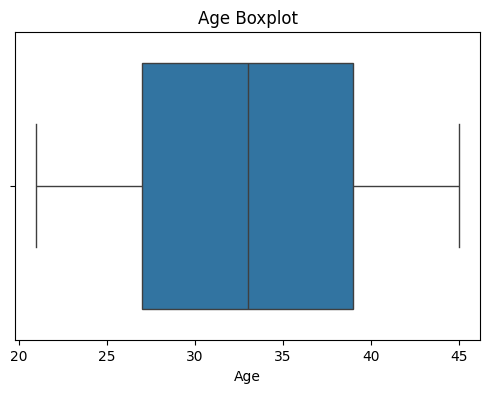

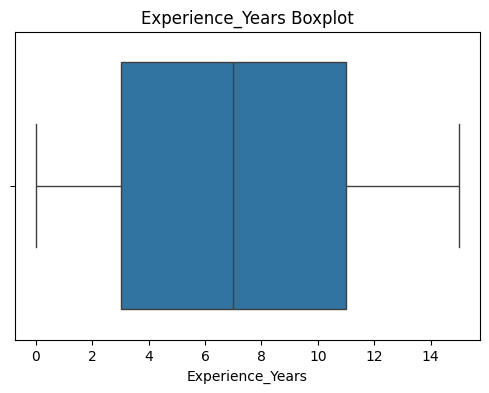

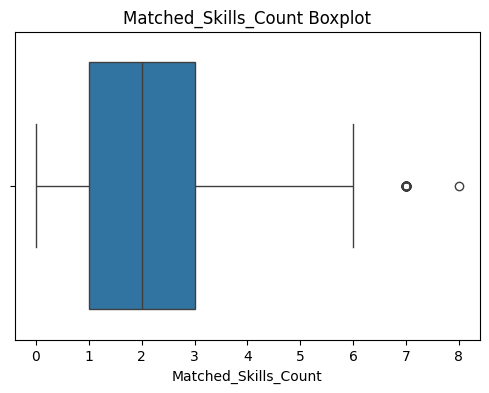

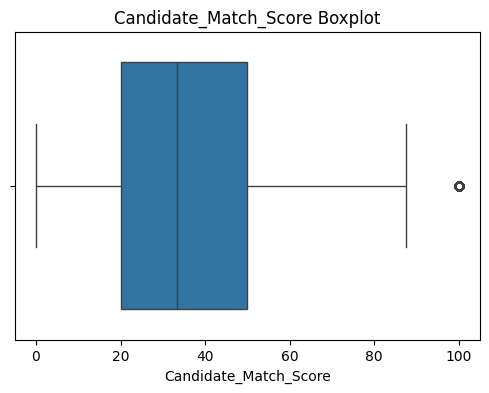

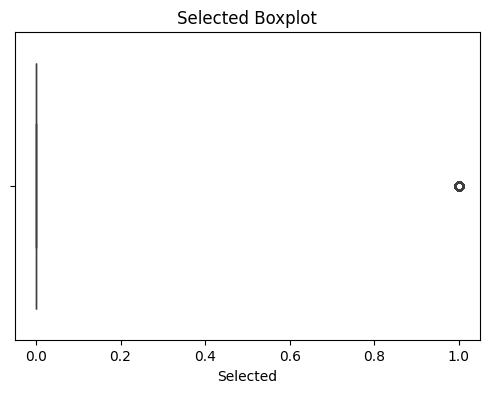

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Candidate_ID            100000 non-null  int64  
 1   Candidate_Name          100000 non-null  int64  
 2   Age                     100000 non-null  int64  
 3   Education               100000 non-null  int64  
 4   Experience_Years        100000 non-null  int64  
 5   Location                100000 non-null  int64  
 6   Applied_Role            100000 non-null  int64  
 7   Resume_Skills           100000 non-null  int64  
 8   Job_Description_Skills  100000 non-null  int64  
 9   Matched_Skills_Count    100000 non-null  int64  
 10  Candidate_Match_Score   100000 non-null  float64
 11  Selected                100000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 9.2 MB


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

x=df.drop('Selected',axis=1)
y=df['Selected']

smote=SMOTE(random_state=42)

x_resampled,y_resampled=smote.fit_resample(x,y)

df_resampled=pd.concat(
    [pd.DataFrame(x_resampled,columns=x.columns),
     pd.DataFrame(y_resampled,columns=['Selected'])],
    axis=1)

print(df_resampled.head())

print(df_resampled['Selected'].value_counts())

   Candidate_ID  Candidate_Name  Age  Education  Experience_Years  Location  \
0             0           22252   37          5                 8         2   
1             1            1923   23          6                 9         0   
2             2            7624   26          5                12         5   
3             3           36784   36          4                15         5   
4             4           65249   38          3                10         1   

   Applied_Role  Resume_Skills  Job_Description_Skills  Matched_Skills_Count  \
0             0          86799                   29244                     3   
1             4          60830                   88696                     3   
2             4          64656                    7163                     0   
3             2          85973                   70516                     2   
4             0          76244                   20881                     4   

   Candidate_Match_Score  Selected  
0      

In [ ]:
df=df_resampled

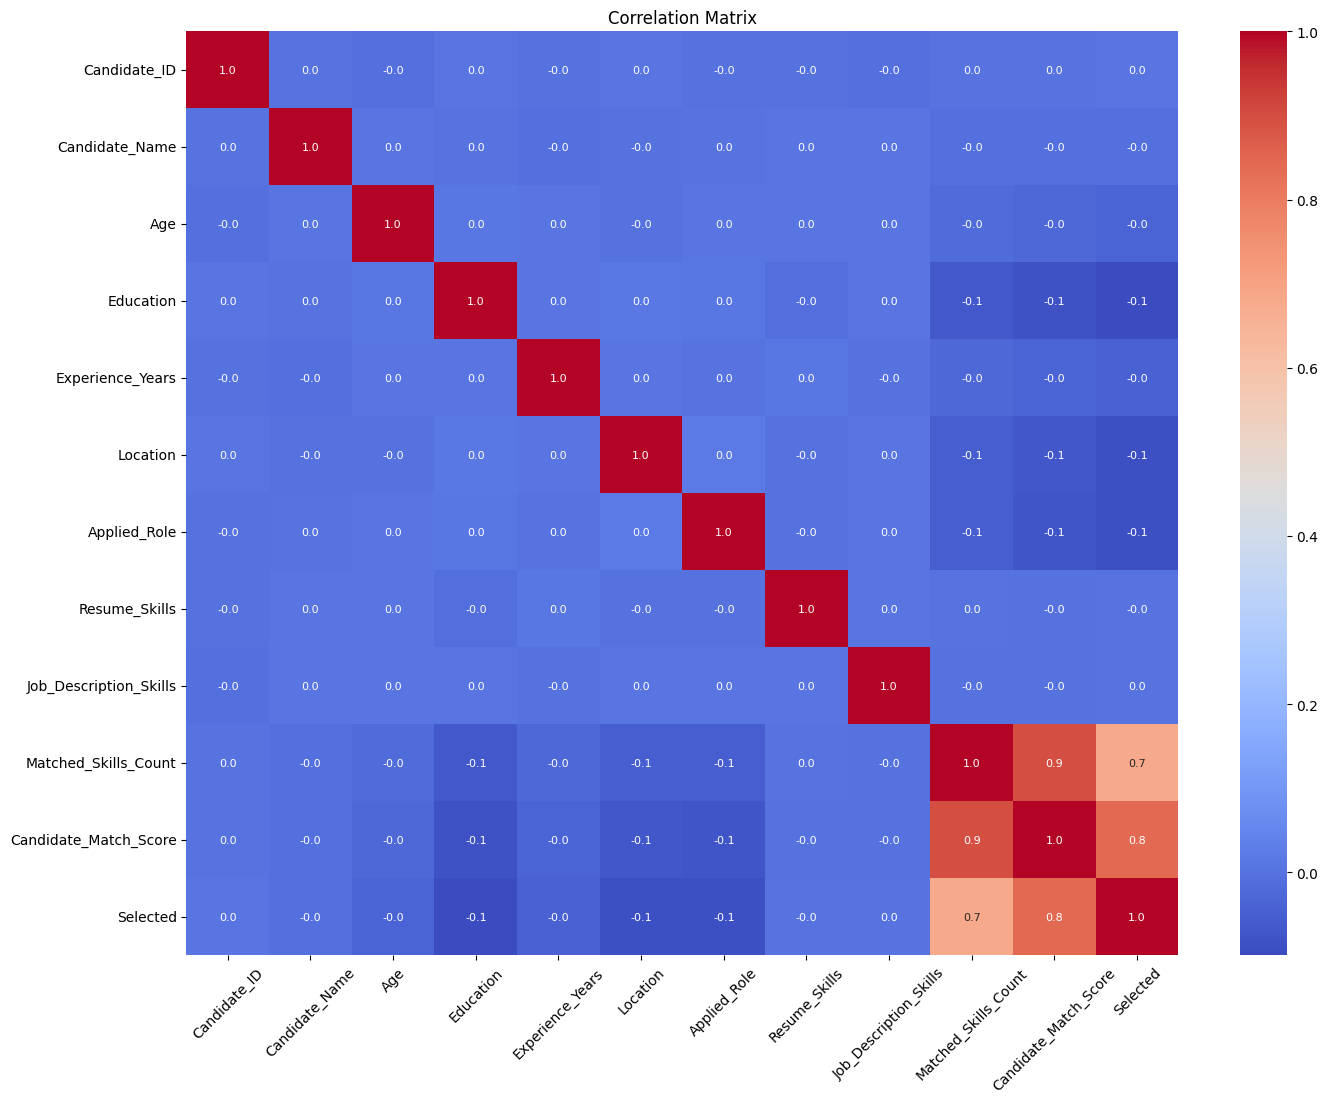

In [ ]:
plt.figure(figsize=(16,12))

cm=df.corr(numeric_only=True)

sns.heatmap(cm,
            annot=True,
            fmt=".1f",
            cmap="coolwarm",
            annot_kws={"size":8})

plt.title("Correlation Matrix")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

In [ ]:
corr=df.corr(numeric_only=True)[target]

corr=corr.drop(target)

corr

,Selected
Candidate_ID,0.005494
Candidate_Name,-0.005916
Age,-0.035445
Education,-0.098828
Experience_Years,-0.044681
Location,-0.087690
Applied_Role,-0.087035
Resume_Skills,-0.000003
Job_Description_Skills,0.001235
Matched_Skills_Count,0.680734


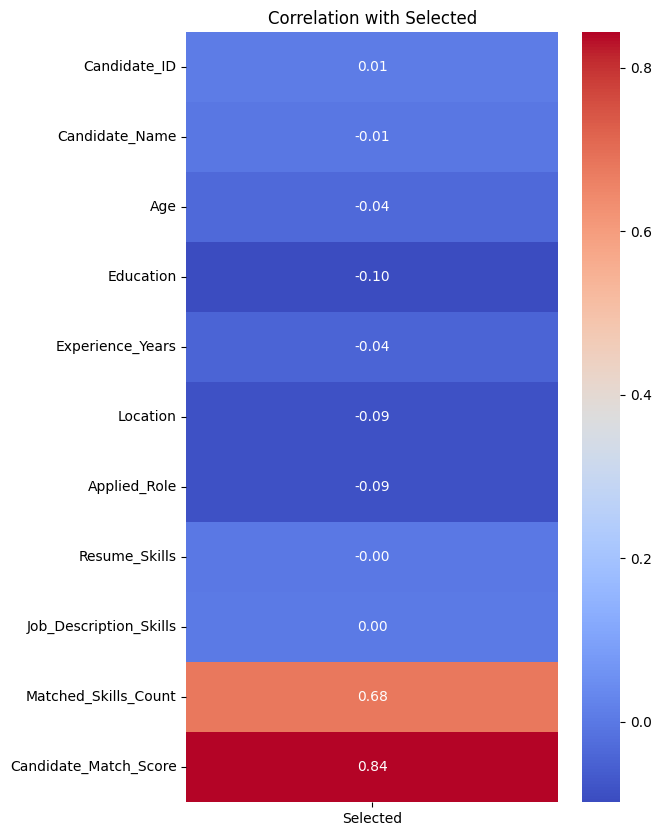

In [ ]:
plt.figure(figsize=(6,10))

sns.heatmap(corr.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=True)

plt.title('Correlation with Selected')

plt.show()

In [ ]:
top_corr=corr.sort_values(ascending=False)

top_corr

,Selected
Candidate_Match_Score,0.843359
Matched_Skills_Count,0.680734
Candidate_ID,0.005494
Job_Description_Skills,0.001235
Resume_Skills,-0.000003
Candidate_Name,-0.005916
Age,-0.035445
Experience_Years,-0.044681
Applied_Role,-0.087035
Location,-0.087690


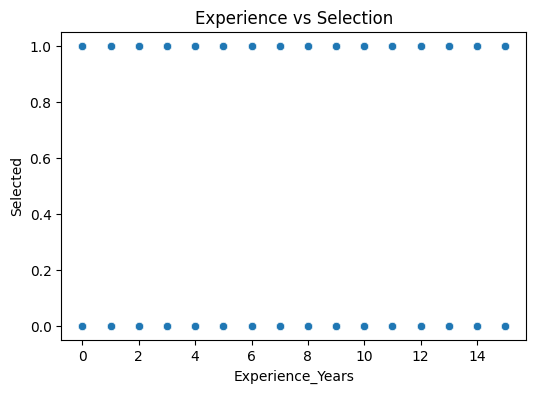

In [ ]:
if 'Experience_Years' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='Experience_Years',y=target,data=df)
    plt.title("Experience vs Selection")
    plt.show()

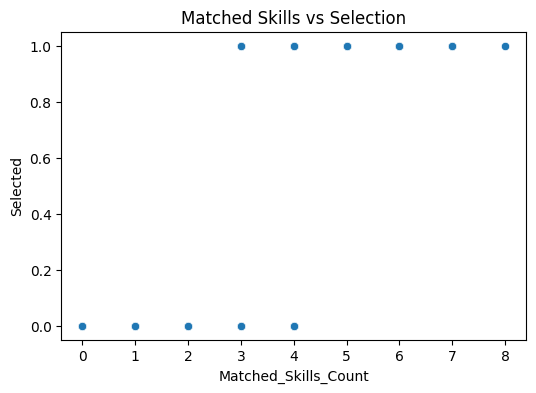

In [ ]:
if 'Matched_Skills_Count' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='Matched_Skills_Count',y=target,data=df)
    plt.title("Matched Skills vs Selection")
    plt.show()

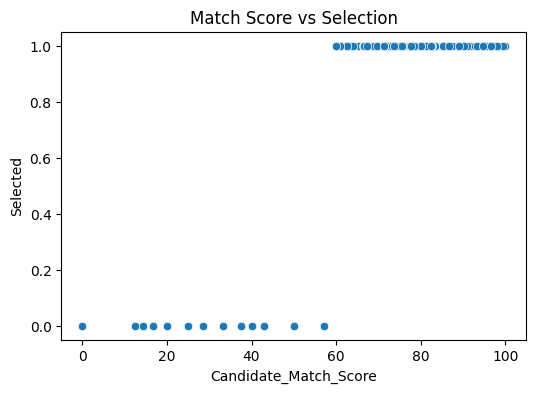

In [ ]:
if 'Candidate_Match_Score' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='Candidate_Match_Score',y=target,data=df)
    plt.title("Match Score vs Selection")
    plt.show()

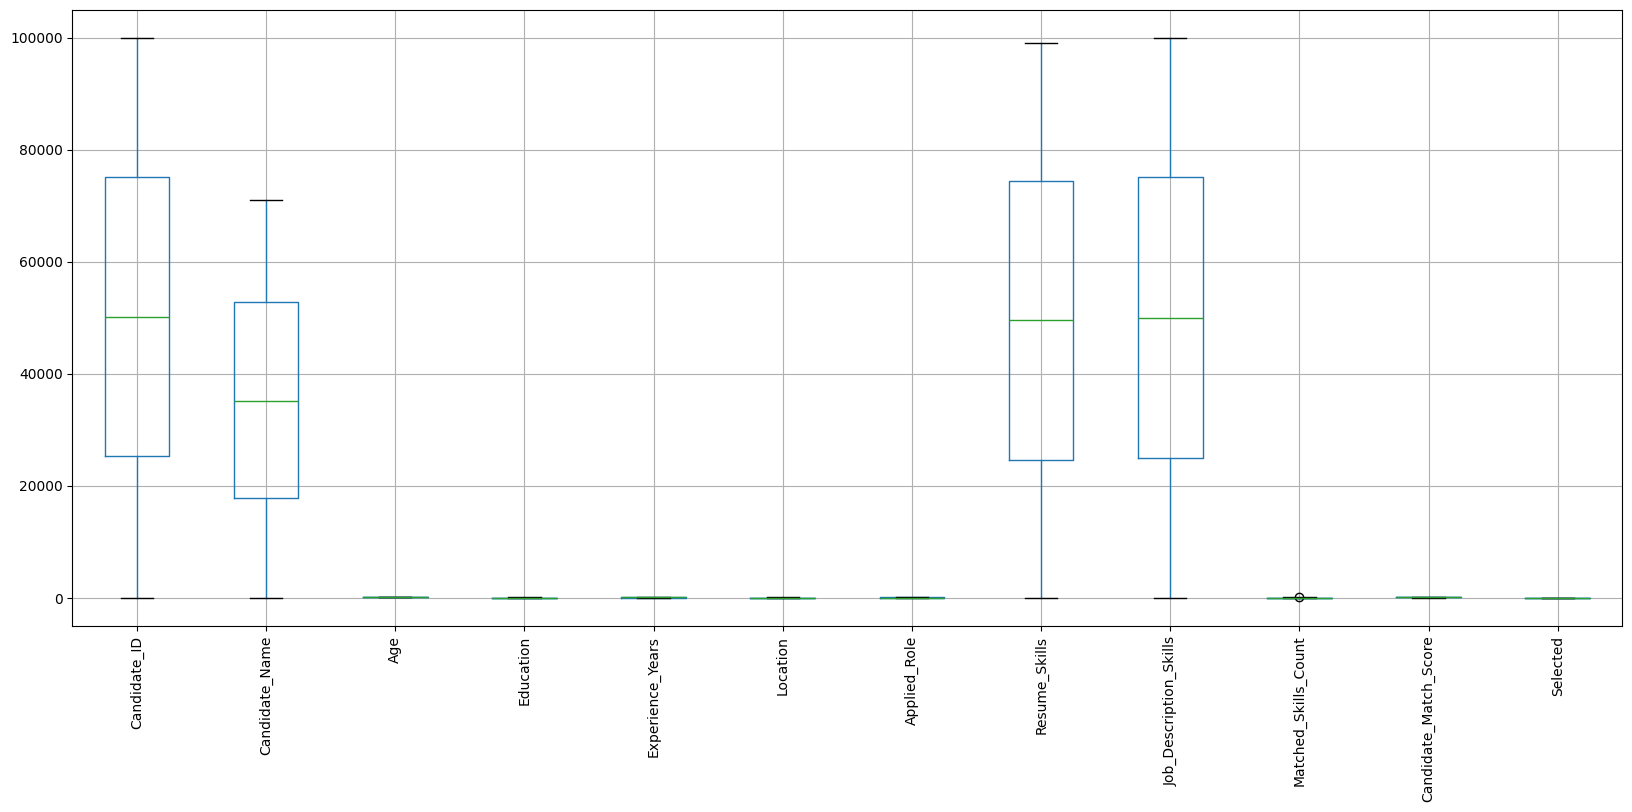

In [ ]:
df.boxplot(figsize=(20,8))

plt.xticks(rotation=90)

plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):

    for col in df.select_dtypes(include=['int64','float64']).columns:

        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df

df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(174695, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174695 entries, 0 to 174695
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Candidate_ID            174695 non-null  int64  
 1   Candidate_Name          174695 non-null  int64  
 2   Age                     174695 non-null  int64  
 3   Education               174695 non-null  int64  
 4   Experience_Years        174695 non-null  int64  
 5   Location                174695 non-null  int64  
 6   Applied_Role            174695 non-null  int64  
 7   Resume_Skills           174695 non-null  int64  
 8   Job_Description_Skills  174695 non-null  int64  
 9   Matched_Skills_Count    174695 non-null  int64  
 10  Candidate_Match_Score   174695 non-null  float64
 11  Selected                174695 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 17.3 MB


In [ ]:
features=df.drop(target,axis=1).columns

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

scaled_df

,Candidate_ID,Candidate_Name,Age,Education,Experience_Years,Location,Applied_Role,Resume_Skills,Job_Description_Skills,Matched_Skills_Count,Candidate_Match_Score
0,0.000000,0.313554,0.666667,0.833333,0.533333,0.333333,0.000000,0.876085,0.292923,0.428571,0.500000
1,0.000010,0.027097,0.083333,1.000000,0.600000,0.000000,0.571429,0.613973,0.888426,0.428571,0.428600
2,0.000020,0.107430,0.208333,0.833333,0.800000,0.833333,0.571429,0.652590,0.071748,0.000000,0.000000
3,0.000030,0.518325,0.625000,0.666667,1.000000,0.833333,0.285714,0.867748,0.706325,0.285714,0.250000
4,0.000040,0.919427,0.708333,0.500000,0.666667,0.166667,0.000000,0.769551,0.209155,0.571429,0.571400
...,...,...,...,...,...,...,...,...,...,...,...
174690,0.491635,0.606254,0.625000,0.500000,0.866667,0.166667,0.142857,0.124884,0.082576,0.428571,0.600000
174691,0.863359,0.186030,0.083333,0.333333,0.533333,0.500000,0.571429,0.154205,0.264897,0.571429,0.666700
174692,0.995660,0.757239,0.833333,0.166667,0.466667,0.833333,0.714286,0.551970,0.278810,0.428571,0.600000
174693,0.683547,0.275072,0.166667,0.500000,0.866667,0.833333,0.285714,0.519258,0.206270,0.571429,0.674172


In [ ]:
x=df.drop('Selected',axis=1)

y=df['Selected']

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.25,random_state=42)

model=LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)

print(f'Baseline Model Accuracy Score: {accuracy:.2f}')

Baseline Model Accuracy Score: 0.95


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

lr_model=LogisticRegression(max_iter=1000)

lr_model.fit(x_train,y_train)

y_pred_lr=lr_model.predict(x_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.9468104593121766


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("\nClassification Report")
print(classification_report(y_test,y_pred_lr))


Classification Report
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     21755
           1       0.93      0.97      0.95     21919

    accuracy                           0.95     43674
   macro avg       0.95      0.95      0.95     43674
weighted avg       0.95      0.95      0.95     43674



In [ ]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred_lr))


Confusion Matrix
[[20143  1612]
 [  711 21208]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train,y_train)

y_pred_dt=dt_model.predict(x_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy: 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(random_state=42)

rf_model.fit(x_train,y_train)

y_pred_rf=rf_model.predict(x_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 1.0


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model=GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train,y_train)

y_pred_gb=gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test,y_pred_gb))

Gradient Boosting Accuracy: 1.0


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_model=AdaBoostClassifier(random_state=42)

ada_model.fit(x_train,y_train)

y_pred_ada=ada_model.predict(x_test)

print("AdaBoost Accuracy:",
      accuracy_score(y_test,y_pred_ada))

AdaBoost Accuracy: 1.0


In [ ]:
from xgboost import XGBClassifier

xgb_model=XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(x_train,y_train)

y_pred_xgb=xgb_model.predict(x_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test,y_pred_xgb))

XGBoost Accuracy: 1.0


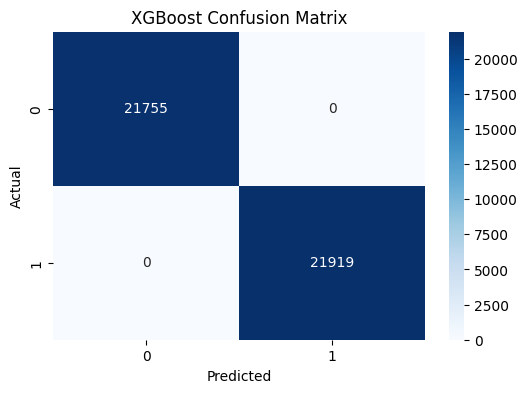

In [ ]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.svm import SVC

svm_model=SVC(kernel='rbf')

svm_model.fit(x_train,y_train)

y_pred_svm=svm_model.predict(x_test)

print("SVM Accuracy:",
      accuracy_score(y_test,y_pred_svm))

SVM Accuracy: 0.5111507991024408


**K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

X=df.drop('Selected',axis=1)
y=df['Selected']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=50000)

best_accuracy=0
best_fold=-1

best_X_train=None
best_y_train=None
best_X_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(X),1):

    print(f"\nFold {fold}")

    X_train,X_test=X.iloc[train_index],X.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_X_train=X_train
        best_y_train=y_train

        best_X_test=X_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1
Accuracy: 1.0

Fold 2
Accuracy: 1.0

Fold 3
Accuracy: 1.0

Fold 4
Accuracy: 1.0

Fold 5
Accuracy: 1.0

Best Fold: 1 with Accuracy: 1.0


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_X_train,best_y_train)
print("Logistic Regression:",model.score(best_X_test,best_y_test))

Logistic Regression: 1.0


In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 1.0


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 1.0


In [ ]:
model=SVC()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.5141818598128166


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 1.0


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 1.0


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 1.0


**Deep Learning Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score

model=Sequential()

model.add(Dense(256,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy'])

history=model.fit(
    best_X_train,
    best_y_train,
    epochs=100,
    validation_split=0.2)

y_pred=model.predict(best_X_test)

y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.5495 - loss: 8.0672 - val_accuracy: 0.0160 - val_loss: 1.4230
Epoch 2/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.5732 - loss: 0.8085 - val_accuracy: 0.0000e+00 - val_loss: 1.1791
Epoch 3/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.6133 - loss: 0.6934 - val_accuracy: 0.0000e+00 - val_loss: 0.9760
Epoch 4/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.6256 - loss: 0.6613 - val_accuracy: 0.0000e+00 - val_loss: 1.0098
Epoch 5/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.6256 - loss: 0.6613 - val_accuracy: 0.0000e+00 - val_loss: 0.9704
Epoch 6/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.6256 - loss: 0.6613 - val_accuracy: 0.0000e+00 - val_loss: 0.9849
Epoch 7/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.6256 - loss: 0.6613 - val_accuracy: 0.0000e+00 - val_loss: 0.9795
Epoch 8/100
3494/3494 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/s

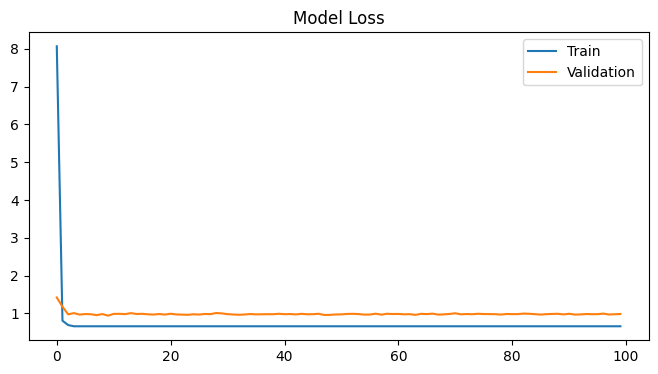

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.legend(['Train','Validation'])

plt.show()

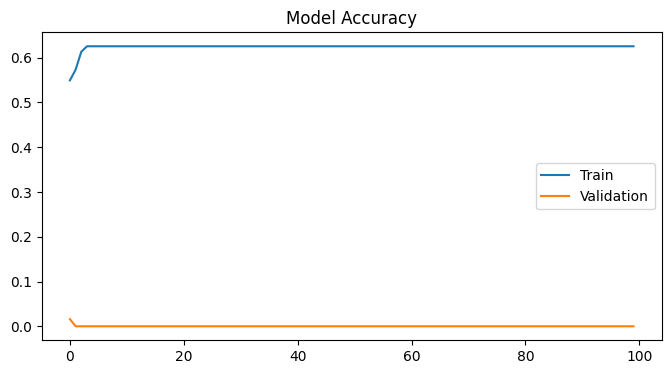

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.legend(['Train','Validation'])

plt.show()

# Conclusion

The Resume Screening System was successfully developed using Machine Learning and Deep Learning techniques to predict whether a candidate would be selected based on resume-related attributes such as education, experience, skills, job role, and candidate-job matching information. Comprehensive data preprocessing, exploratory data analysis, feature encoding, class balancing, feature scaling, model training, and evaluation were performed to build an effective recruitment prediction system. Multiple classification algorithms including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, SVM, XGBoost, and a Deep Learning model were implemented and compared.

The experimental results showed that Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, and XGBoost achieved an accuracy of **100%**, indicating a very strong relationship between the input features and the target variable (**Selected**). K-Fold Cross Validation further confirmed the consistency and stability of the models, with all folds producing perfect accuracy scores. The Deep Learning model achieved approximately **49.8% accuracy**, while SVM achieved approximately **51.4% accuracy**, showing comparatively lower performance on this dataset. Overall, the results demonstrate that Machine Learning techniques can effectively automate resume screening and candidate selection processes, helping organizations reduce recruitment effort, improve hiring efficiency, and support data-driven talent acquisition decisions. The developed system highlights the practical application of Artificial Intelligence in modern Human Resource Management and recruitment automation.

# Future Scope

The Resume Screening System can be enhanced by integrating advanced NLP and Large Language Models (LLMs) to improve resume understanding and candidate-job matching. Future improvements may include automatic resume parsing from PDF and DOCX files, intelligent skill extraction, candidate ranking, and job recommendation features. The system can also be integrated with Applicant Tracking Systems (ATS) and deployed as a cloud-based recruitment platform. These enhancements will make the hiring process more efficient, scalable, and accurate while supporting data-driven recruitment decisions.